
##### ¿Qué es la Regresión Lineal Simple?

Modela la relación entre una variable de entrada (X) y una salida (y) con una línea recta:
**ŷ = β₀ + β₁ · X**<br>

---

β₀ → Intercepto (valor de y cuando X = 0)<br>
β₁ → Pendiente (cuánto aumenta y por cada unidad de X)<br>
*X* → Años de experiencia<br>
*ŷ* → Salario estimado<br>
*Intuición*: Es la línea que "mejor se ajusta" a la nube de puntos del scatter plot.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use("seaborn-v0_8-whitegrid")
print("Project imports and settings ready")

Project imports and settings ready


In [ ]:
path = kagglehub.dataset_download("abhishek14398/salary-dataset-simple-linear-regression")
print("Path to dataset files:", path)

df = pd.read_csv(os.path.join(path, 'salary_dataset.csv'))
df.head()

Path to dataset files: C:\Users\anahi\.cache\kagglehub\datasets\abhishek14398\salary-dataset-simple-linear-regression\versions\1


,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [4]:
df.sample(5)

,Unnamed: 0,YearsExperience,Salary
5,5,3.0,56643.0
21,21,7.2,98274.0
2,2,1.6,37732.0
18,18,6.0,81364.0
14,14,4.6,61112.0


In [9]:
df.shape

(30, 3)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


In [11]:
df.isnull().sum()

Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64

In [12]:
df.describe().round(2)

,Unnamed: 0,YearsExperience,Salary
count,30.00,30.00,30.00
mean,14.50,5.41,76004.00
std,8.80,2.84,27414.43
min,0.00,1.20,37732.00
25%,7.25,3.30,56721.75
50%,14.50,4.80,65238.00
75%,21.75,7.80,100545.75
max,29.00,10.60,122392.00


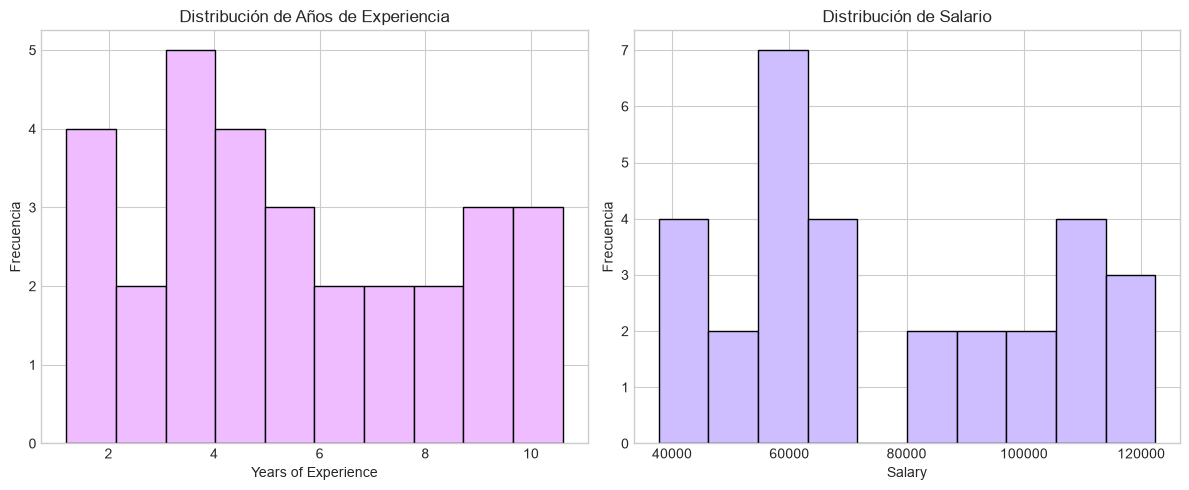

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(df['YearsExperience'], bins=10, color='#EFBDFF', edgecolor='black')
axes[0].set_title('Distribución de Años de Experiencia')
axes[0].set_xlabel('Years of Experience')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(df['Salary'], bins=10, color='#CEBDFF', edgecolor='black')
axes[1].set_title('Distribución de Salario')
axes[1].set_xlabel('Salary')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()


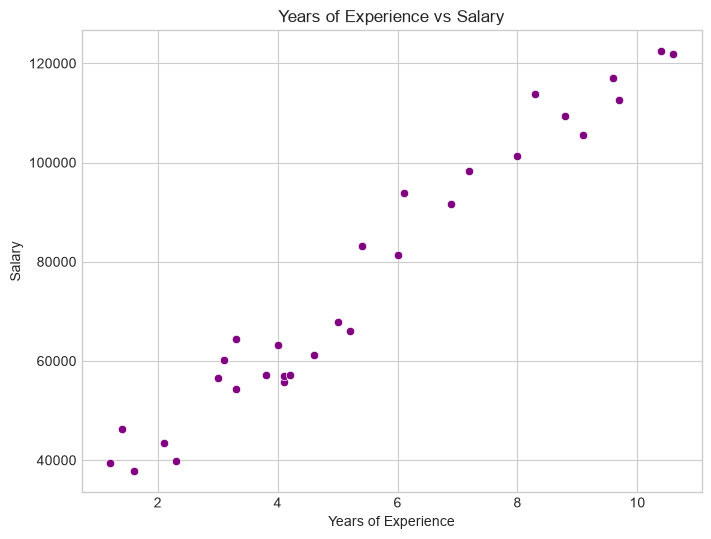

In [15]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='YearsExperience', y='Salary', color='purple')
plt.title('Years of Experience vs Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

In [16]:
correlation = df['YearsExperience'].corr(df['Salary'])
print(f"Correlación de Pearson: {correlation:.4f}")

if correlation > 0.95:
    print("Correlación excelente para regresión lineal")
elif correlation > 0.7:
    print("Correlación fuerte, adecuada para regresión lineal")
else:
    print("Correlación débil, la regresión lineal podría no ser el mejor modelo")

Correlación de Pearson: 0.9782
Correlación excelente para regresión lineal


In [18]:
X = df[['YearsExperience']]
y = df['Salary']

print(X.shape)
print(y.shape)

(30, 1)
(30,)


In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Muestras de entrenamiento: {X_train.shape[0]}")
print(f"Muestras de prueba: {X_test.shape[0]}")

Muestras de entrenamiento: 24
Muestras de prueba: 6


β₀ (intercepto): 24380.20
β₁ (pendiente): 9423.82


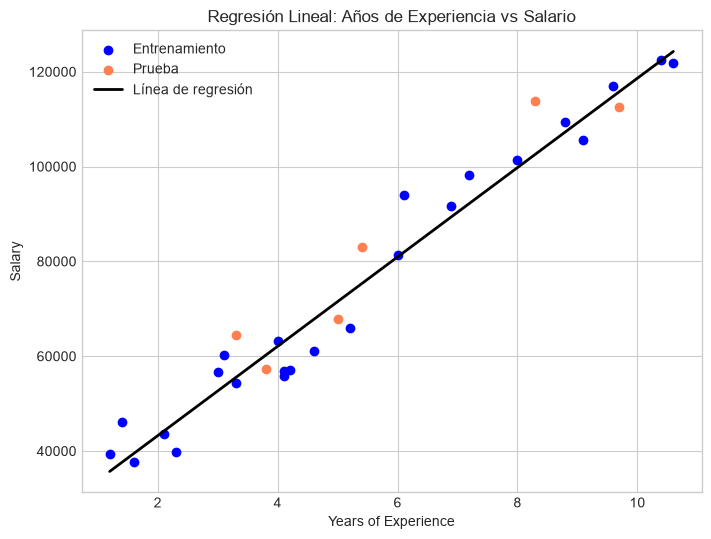

In [21]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

print(f"β₀ (intercepto): {modelo.intercept_:.2f}")
print(f"β₁ (pendiente): {modelo.coef_[0]:.2f}")

X_linea = pd.DataFrame(np.linspace(X['YearsExperience'].min(), X['YearsExperience'].max(), 100), columns=['YearsExperience'])
y_linea = modelo.predict(X_linea)

plt.figure(figsize=(8, 6))
plt.scatter(X_train, y_train, color='blue', label='Entrenamiento')
plt.scatter(X_test, y_test, color='coral', label='Prueba')
plt.plot(X_linea, y_linea, color='black', linewidth=2, label='Línea de regresión')
plt.title('Regresión Lineal: Años de Experiencia vs Salario')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.show()

In [22]:
from sklearn.metrics import r2_score

y_pred = modelo.predict(X_test)

comparacion = pd.DataFrame({
    'Años_Exp': X_test['YearsExperience'].values,
    'Salario_Real': y_test.values,
    'Salario_Predicho': y_pred,
    'Error': y_test.values - y_pred
})

print(comparacion)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: ${mae:,.2f}")
print(f"MSE: {mse:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R²: {r2:.4f}")

   Años_Exp  Salario_Real  Salario_Predicho         Error
0       9.7      112636.0     115791.210113  -3155.210113
1       5.0       67939.0      71499.278095  -3560.278095
2       8.3      113813.0     102597.868661  11215.131339
3       5.4       83089.0      75268.804224   7820.195776
4       3.3       64446.0      55478.792045   8967.207955
5       3.8       57190.0      60190.699707  -3000.699707
MAE: $6,286.45
MSE: 49,830,096.86
RMSE: $7,059.04
R²: 0.9024


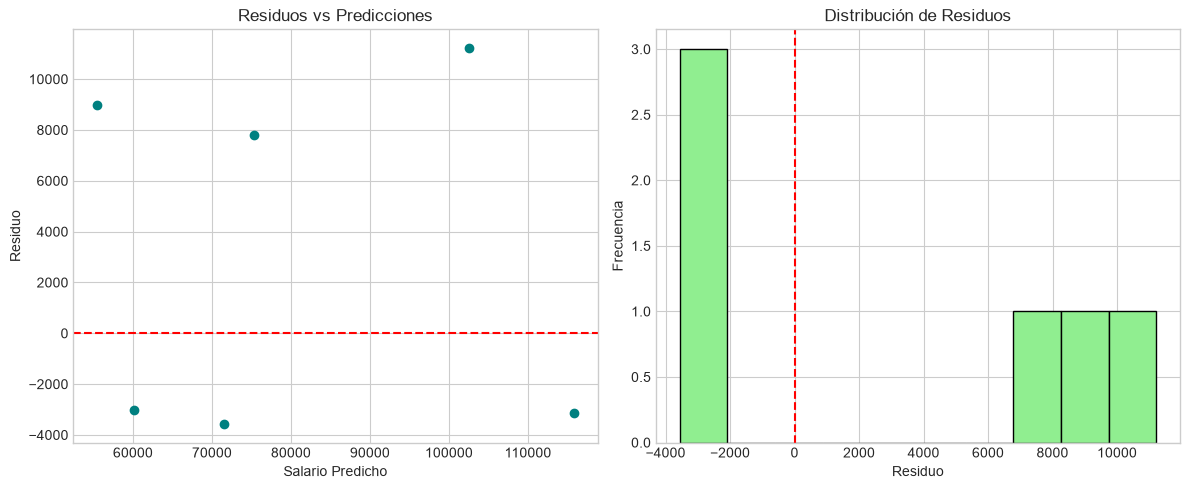

In [23]:
residuos = y_test.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_pred, residuos, color='teal')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title('Residuos vs Predicciones')
axes[0].set_xlabel('Salario Predicho')
axes[0].set_ylabel('Residuo')

axes[1].hist(residuos, bins=10, color='lightgreen', edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_title('Distribución de Residuos')
axes[1].set_xlabel('Residuo')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [24]:
umbral = 2 * residuos.std()
indices_outliers = np.where(np.abs(residuos) > umbral)[0]

print(f"Umbral de error: ${umbral:,.2f}")
print(f"Número de outliers: {len(indices_outliers)}")

for i in indices_outliers:
    print(f"Años_Exp: {X_test['YearsExperience'].values[i]}, Real: {y_test.values[i]:.2f}, Predicho: {y_pred[i]:.2f}, Error: {residuos[i]:.2f}")

Umbral de error: $12,734.44
Número de outliers: 0


In [25]:
r2_train = modelo.score(X_train, y_train)
r2_test = modelo.score(X_test, y_test)
diferencia = r2_train - r2_test

print(f"R² entrenamiento: {r2_train:.4f}")
print(f"R² prueba: {r2_test:.4f}")
print(f"Diferencia: {diferencia:.4f}")

if diferencia > 0.10:
    print("Posible overfitting")
else:
    print("No hay evidencia de overfitting")

R² entrenamiento: 0.9645
R² prueba: 0.9024
Diferencia: 0.0621
No hay evidencia de overfitting


In [26]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(modelo, X, y, cv=5, scoring='r2')

print(f"R² por fold: {scores}")
print(f"R² promedio: {scores.mean():.4f}")
print(f"Desviación estándar: {scores.std():.4f}")

R² por fold: [ 0.3595933  -1.24422823  0.25052696  0.29699762  0.07028896]
R² promedio: -0.0534
Desviación estándar: 0.6032


In [27]:
nuevos_datos = pd.DataFrame({'YearsExperience': [1.5, 5.0, 8.0, 10.0, 12.0]})
predicciones_nuevas = modelo.predict(nuevos_datos)

for años, salario in zip(nuevos_datos['YearsExperience'], predicciones_nuevas):
    print(f"Años de experiencia: {años} → Salario estimado: ${salario:,.2f}")

Años de experiencia: 1.5 → Salario estimado: $38,515.92
Años de experiencia: 5.0 → Salario estimado: $71,499.28
Años de experiencia: 8.0 → Salario estimado: $99,770.72
Años de experiencia: 10.0 → Salario estimado: $118,618.35
Años de experiencia: 12.0 → Salario estimado: $137,465.99


In [28]:
print("Resumen del Modelo de Regresión Lineal")
print(f"Ecuación: Salario = {modelo.intercept_:.2f} + {modelo.coef_[0]:.2f} × Años")
print()
print(f"R² (prueba): {r2:.4f} {'✅' if r2 >= 0.90 else '⚠️'}")
print(f"MAE (prueba): ${mae:,.2f} {'✅' if mae < 5000 else '⚠️'}")
print(f"RMSE (prueba): ${rmse:,.2f}")
print()
print(f"R² promedio (validación cruzada): {scores.mean():.4f}")

Resumen del Modelo de Regresión Lineal
Ecuación: Salario = 24380.20 + 9423.82 × Años

R² (prueba): 0.9024 ✅
MAE (prueba): $6,286.45 ⚠️
RMSE (prueba): $7,059.04

R² promedio (validación cruzada): -0.0534
